# SBV2 08 - Image-Generation Readiness Scoring

This notebook turns Notebook 7 extraction metrics into a practical signal gate for image-generation work: structured prompt-pack pairs, captioned style-reference pairs, review candidates, and controls.

## Contract

Inputs:

- `data/processed/sandbox_v2/extraction_metrics.csv`
- `data/processed/sandbox_v2/menu_generation_schema.csv`
- `data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv`

Outputs:

- `data/processed/sandbox_v2/readiness_scores.csv`
- `data/processed/sandbox_v2/readiness_scores.parquet`
- `outputs/sandbox_v2/audit_tables/sbv2_08_readiness_scores.csv`
- `outputs/sandbox_v2/audit_tables/sbv2_08_readiness_source_summary.csv`
- `outputs/sandbox_v2/audit_tables/sbv2_08_prompt_pack_candidates.csv`
- `outputs/sandbox_v2/audit_tables/sbv2_08_finetune_signal_candidates.csv`
- `outputs/figures/sandbox_v2/sbv2_08_readiness_scores.png`

This notebook does not train an image model. It answers the earlier question first: whether our OCR/schema/layout signals are strong enough to create useful supervision for generation and possible later fine-tuning.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "sandbox_v2").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)
ROOT

PosixPath('/home/endy/menuforge')

In [2]:
# Keep this deterministic and cheap. The helper only reads Notebook 7 outputs and writes audit tables.
RUN_READINESS = True

### Preflight

In [3]:
preflight_paths = {
    "extraction_metrics": ROOT / "data/processed/sandbox_v2/extraction_metrics.csv",
    "menu_generation_schema": ROOT / "data/processed/sandbox_v2/menu_generation_schema.csv",
    "document_manifest": ROOT / "data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv",
}
preflight = pd.DataFrame(
    [
        {
            "input": name,
            "path": str(path.relative_to(ROOT)),
            "exists": path.exists(),
            "bytes": path.stat().st_size if path.exists() else 0,
        }
        for name, path in preflight_paths.items()
    ]
)
display(preflight)
missing = preflight.loc[~preflight["exists"], "path"].tolist()
if missing:
    raise FileNotFoundError(f"Run earlier SBV2 notebooks first; missing: {missing}")

,input,path,exists,bytes
0,extraction_metrics,data/processed/sandbox_v2/extraction_metrics.csv,True,3527
1,menu_generation_schema,data/processed/sandbox_v2/menu_generation_schema.csv,True,136419
2,document_manifest,data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv,True,1293172


In [4]:
from sandbox_v2.readiness_scoring import write_outputs

if RUN_READINESS:
    summary = write_outputs()
else:
    summary_path = ROOT / "outputs/sandbox_v2/audit_tables/sbv2_08_readiness_summary.json"
    summary = json.loads(summary_path.read_text(encoding="utf-8"))

print(json.dumps(summary, indent=2))

{
  "created_at": "2026-04-29T20:02:12",
  "run_name": "sbv2_08_readiness_scoring",
  "document_rows": 8,
  "ready_for_generation": 2,
  "needs_review": 1,
  "do_not_generate": 5,
  "prompt_pack_candidates": 2,
  "finetune_signal_candidates": 4,
  "style_reference_candidates": 2,
  "eval_control_candidates": 3,
  "mean_readiness_score": 0.726,
  "mean_image_pair_signal_score": 0.7399,
  "readiness_scores_csv": "data/processed/sandbox_v2/readiness_scores.csv",
  "readiness_scores_parquet": "data/processed/sandbox_v2/readiness_scores.parquet",
  "audit_readiness_scores_csv": "outputs/sandbox_v2/audit_tables/sbv2_08_readiness_scores.csv",
  "source_summary_csv": "outputs/sandbox_v2/audit_tables/sbv2_08_readiness_source_summary.csv",
  "label_counts_csv": "outputs/sandbox_v2/audit_tables/sbv2_08_readiness_label_counts.csv",
  "prompt_pack_candidates_csv": "outputs/sandbox_v2/audit_tables/sbv2_08_prompt_pack_candidates.csv",
  "finetune_signal_candidates_csv": "outputs/sandbox_v2/audit_tabl

In [5]:
def _read_csv_from_summary(key: str) -> pd.DataFrame:
    path = ROOT / summary[key]
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    return pd.read_csv(path)

scores = _read_csv_from_summary("audit_readiness_scores_csv")
source_summary = _read_csv_from_summary("source_summary_csv")
label_counts = _read_csv_from_summary("label_counts_csv")
prompt_pack = _read_csv_from_summary("prompt_pack_candidates_csv")
finetune_candidates = _read_csv_from_summary("finetune_signal_candidates_csv")

summary_view = pd.DataFrame(
    [
        {"metric": key, "value": summary.get(key)}
        for key in [
            "document_rows",
            "ready_for_generation",
            "needs_review",
            "do_not_generate",
            "prompt_pack_candidates",
            "finetune_signal_candidates",
            "style_reference_candidates",
            "eval_control_candidates",
            "mean_readiness_score",
            "mean_image_pair_signal_score",
        ]
    ]
)
display(summary_view)

,metric,value
0,document_rows,8.0000
1,ready_for_generation,2.0000
2,needs_review,1.0000
3,do_not_generate,5.0000
4,prompt_pack_candidates,2.0000
5,finetune_signal_candidates,4.0000
6,style_reference_candidates,2.0000
7,eval_control_candidates,3.0000
8,mean_readiness_score,0.7260
9,mean_image_pair_signal_score,0.7399


In [6]:
display(label_counts)
display(source_summary.sort_values(["finetune_signal_candidates", "mean_image_pair_signal_score"], ascending=[False, False]))

,readiness_label,documents
0,do_not_generate,5
1,needs_review,1
2,ready_for_generation,2


,source_id,documents,ready_for_generation,needs_review,do_not_generate,prompt_pack_candidates,finetune_signal_candidates,style_reference_candidates,eval_control_candidates,mean_readiness_score,mean_image_pair_signal_score
5,synthetic_menu_concepts,1,1,0,0,1,1,0,0,0.9642,0.9611
3,nypl_expanded,1,1,0,0,1,1,0,0,0.9457,0.9438
7,wikimedia_english_menus,1,0,0,1,0,1,1,0,0.9120,0.9079
6,wikimedia_commons_english_menus,1,0,0,1,0,1,1,0,0.9116,0.9063
2,nypl,1,0,1,0,0,0,0,0,0.8899,0.9119
1,funsd,1,0,0,1,0,0,0,1,0.4052,0.4404
4,sroie,1,0,0,1,0,0,0,1,0.3923,0.4264
0,cord,1,0,0,1,0,0,0,1,0.3873,0.4210


In [7]:
candidate_cols = [
    "source_id",
    "document_id",
    "readiness_label",
    "readiness_score",
    "image_pair_signal_score",
    "caption_signal_score",
    "layout_signal_score",
    "style_signal_score",
    "image_generation_use",
    "finetune_signal_candidate",
    "style_reference_candidate",
    "eval_control_candidate",
    "training_signal_role",
    "blockers",
]

display(scores[candidate_cols].sort_values("image_pair_signal_score", ascending=False))
print("Prompt-pack candidates")
display(prompt_pack[candidate_cols])
print("Fine-tune signal candidates")
display(finetune_candidates[candidate_cols])

,source_id,document_id,readiness_label,readiness_score,image_pair_signal_score,caption_signal_score,layout_signal_score,style_signal_score,image_generation_use,finetune_signal_candidate,style_reference_candidate,eval_control_candidate,training_signal_role,blockers
4,synthetic_menu_concepts,synthetic_menu_concept_0000,ready_for_generation,0.9642,0.9611,0.9287,0.9067,0.9990,structured_image_text_pair,True,False,False,synthetic_control_training_signal,NaN
3,nypl_expanded,nypl_expanded_144,ready_for_generation,0.9457,0.9438,0.9610,0.9863,0.9905,structured_image_text_pair,True,False,False,structured_menu_image_text_pair,NaN
2,nypl,nypl_page_45078,needs_review,0.8899,0.9119,0.8844,1.0000,0.9751,review_before_structured_pair,False,False,False,needs_human_review_before_training,schema_validity_below_threshold;manual_review_rate_high
6,wikimedia_english_menus,wikimedia_menu_000,do_not_generate,0.9120,0.9079,0.9825,0.9968,0.9915,style_caption_sidecar,True,True,False,style_reference_caption_pair,sidecar_not_primary_menu_extraction
5,wikimedia_commons_english_menus,wikimedia_commons_0000,do_not_generate,0.9116,0.9063,0.9829,1.0000,0.9885,style_caption_sidecar,True,True,False,style_reference_caption_pair,sidecar_not_primary_menu_extraction
1,funsd,funsd_0,do_not_generate,0.4052,0.4404,0.2158,0.0000,0.5198,ocr_negative_control,False,False,True,negative_or_robustness_control,not_menu_visual;no_schema_rows
0,sroie,sroie_00000,do_not_generate,0.3923,0.4264,0.2005,0.0000,0.5071,ocr_negative_control,False,False,True,negative_or_robustness_control,not_menu_visual;no_schema_rows
7,cord,cord_smoke_0000,do_not_generate,0.3873,0.4210,0.2109,0.0000,0.5158,ocr_negative_control,False,False,True,negative_or_robustness_control,not_menu_visual;no_schema_rows


Prompt-pack candidates


,source_id,document_id,readiness_label,readiness_score,image_pair_signal_score,caption_signal_score,layout_signal_score,style_signal_score,image_generation_use,finetune_signal_candidate,style_reference_candidate,eval_control_candidate,training_signal_role,blockers
0,nypl_expanded,nypl_expanded_144,ready_for_generation,0.9457,0.9438,0.9610,0.9863,0.9905,structured_image_text_pair,True,False,False,structured_menu_image_text_pair,NaN
1,synthetic_menu_concepts,synthetic_menu_concept_0000,ready_for_generation,0.9642,0.9611,0.9287,0.9067,0.9990,structured_image_text_pair,True,False,False,synthetic_control_training_signal,NaN


Fine-tune signal candidates


,source_id,document_id,readiness_label,readiness_score,image_pair_signal_score,caption_signal_score,layout_signal_score,style_signal_score,image_generation_use,finetune_signal_candidate,style_reference_candidate,eval_control_candidate,training_signal_role,blockers
0,nypl_expanded,nypl_expanded_144,ready_for_generation,0.9457,0.9438,0.9610,0.9863,0.9905,structured_image_text_pair,True,False,False,structured_menu_image_text_pair,NaN
1,synthetic_menu_concepts,synthetic_menu_concept_0000,ready_for_generation,0.9642,0.9611,0.9287,0.9067,0.9990,structured_image_text_pair,True,False,False,synthetic_control_training_signal,NaN
2,wikimedia_commons_english_menus,wikimedia_commons_0000,do_not_generate,0.9116,0.9063,0.9829,1.0000,0.9885,style_caption_sidecar,True,True,False,style_reference_caption_pair,sidecar_not_primary_menu_extraction
3,wikimedia_english_menus,wikimedia_menu_000,do_not_generate,0.9120,0.9079,0.9825,0.9968,0.9915,style_caption_sidecar,True,True,False,style_reference_caption_pair,sidecar_not_primary_menu_extraction


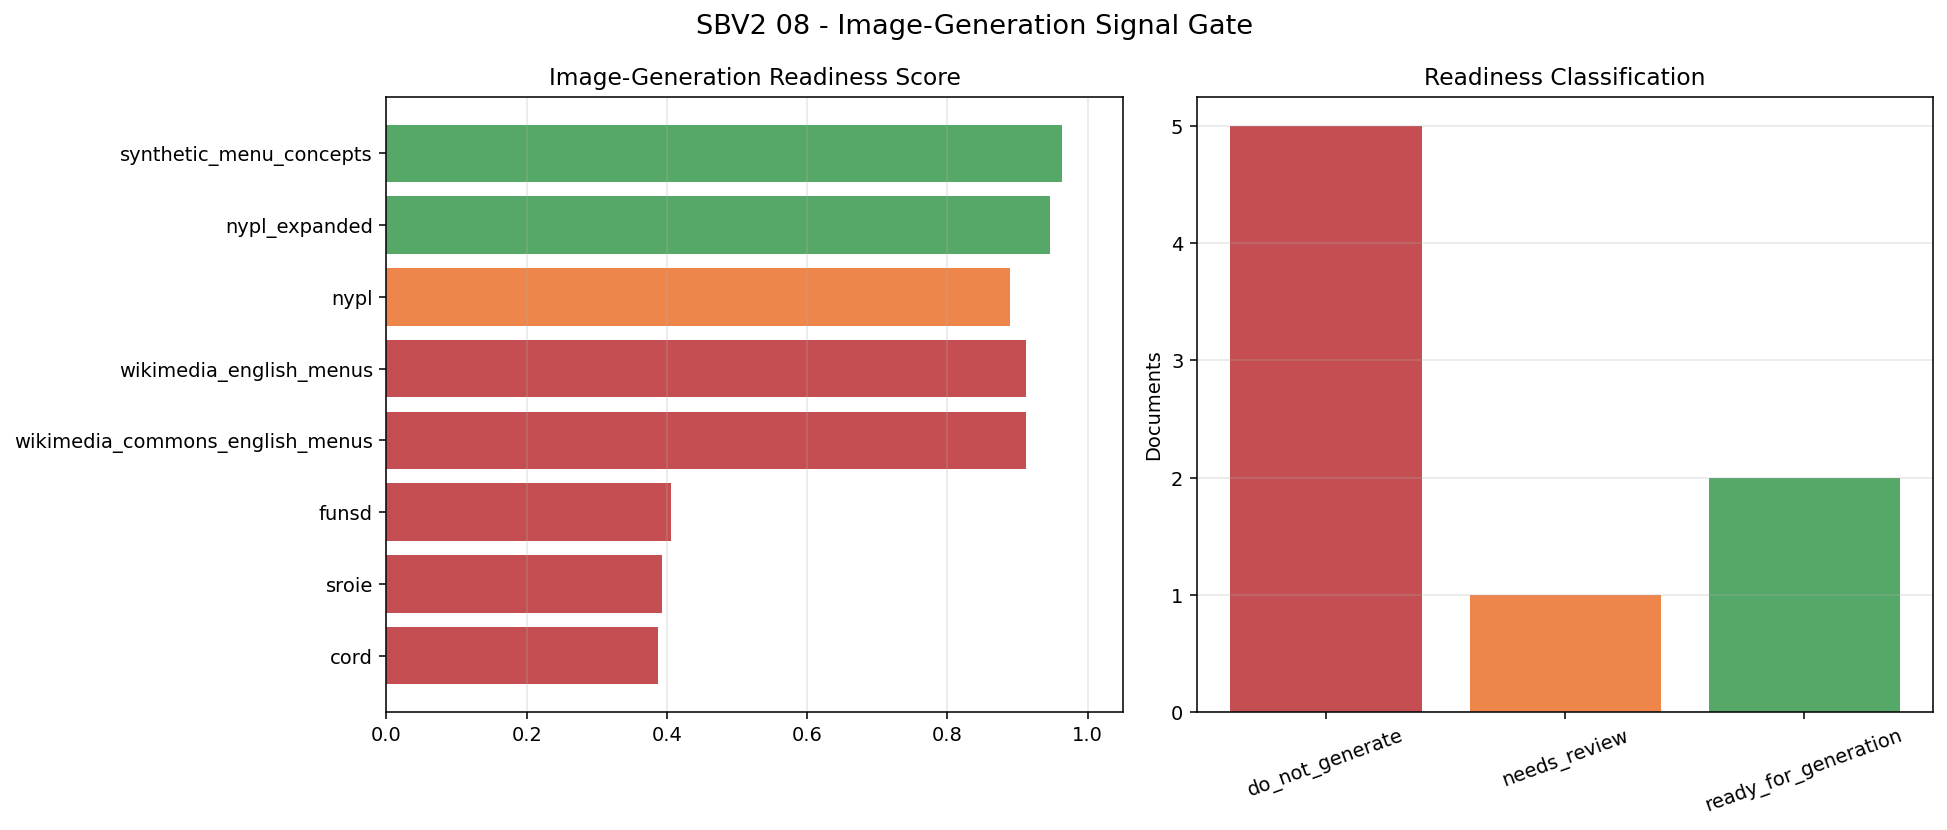

In [8]:
figure = ROOT / summary["figure"]
if figure.exists():
    display(Image(filename=str(figure)))
else:
    print(f"Figure not found: {figure}")

## Interpretation

Yes: the pipeline can help image-generation models, because it converts raw/private menu images into higher-quality image-text-layout supervision instead of weak captions. Notebook 8 does not prove a fine-tune will succeed; it proves whether the data is worth taking into a generation or adapter experiment.

Read the roles this way:

- `structured_menu_image_text_pair`: usable for prompt packs and later image-generation pair tests.
- `synthetic_control_training_signal`: exact local control pair; useful for checking whether the downstream generator follows structured menu prompts.
- `style_reference_caption_pair`: useful for style/layout conditioning, but not trusted as a full structured menu target.
- `needs_human_review_before_training`: likely useful, but schema noise is still high.
- `negative_or_robustness_control`: proves the gate is not blindly accepting every OCR document.

The important caveat stays technical, not legal: image generators should not be trusted to render exact menu text and prices. The strongest path is still structured schema plus deterministic render checks, with fine-tuning used for style, visual treatment, and controllability.

## Handoff to Notebook 09

Notebook 09 should build prompt/caption packs from `sbv2_08_prompt_pack_candidates.csv` and `sbv2_08_finetune_signal_candidates.csv`. It should keep structured prompt tests separate from style-reference experiments so we can tell whether the pipeline improves controllability before any expensive generation run.